# Architecture and training histories

Reproduce the architecture schematic (Figure 2a), Chilean training snapshots (Figure 2b), and country-specific learning curves (Figure S1). Snapshots describe optimization, not changes in opinions over time.

**Inputs:** `assets/architecture*.svg`, the saved Chilean `model_specification.json` in `outputs/models/Chile_dim2_seed101`, and the training files in `data/processed/figure_inputs/training`. Notebook 09 regenerates the training inputs from the fits in notebooks 02–03. All required files are included.

**Outputs:** `outputs/panels/Fig2a.pdf`, `Fig2b.pdf`, the selected editable SVG, `outputs/figures/FigS1.pdf`, and supporting tables in `outputs/tables`.

**Run or explore:** run all cells in a fresh kernel. No model training is performed. The architecture labels come from the saved fit, so editing plot settings cannot mislabel its network. Figure 2a requires the `rsvg-convert` command from librsvg.


These maps show two-dimensional coordinates. Change `SNAPSHOT_EPOCHS` to choose four available snapshots. Training curves use the full saved history of each country.

In [1]:
from pathlib import Path
import shutil
import json
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, SVG

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
assert (ROOT / "data/raw").is_dir(), "Open from the project root or notebooks directory."

SNAPSHOT_EPOCHS = [0, 5, 10, 20]
# Figure 2B has four panels. Select four snapshots saved by notebook 02.
assert len(SNAPSHOT_EPOCHS) == len(set(SNAPSHOT_EPOCHS)) == 4

MODEL_SPECIFICATION = json.loads(
    (ROOT / "outputs/models/Chile_dim2_seed101/model_specification.json").read_text()
)
VARIANT = MODEL_SPECIFICATION["variant"]
assert VARIANT in {"original", "intermediate"}
assert MODEL_SPECIFICATION["dimension"] == 2


## Local input and output paths

The following cells use the included training snapshots and histories. Plot styling can be changed without altering the model specification.


In [2]:
DATA = ROOT / "data/processed/figure_inputs/training"
PANELS = ROOT / "outputs/panels"
FIGURES = ROOT / "outputs/figures"
TABLES = ROOT / "outputs/tables"
assert (
    DATA / "DataTraining_and_Validation_Accuracy_Loss.csv"
).is_file(), "Run from the release root or its notebooks directory."
for directory in (PANELS, FIGURES, TABLES):
    directory.mkdir(parents=True, exist_ok=True)
plt.rcParams.update(
    {
        "font.family": "DejaVu Sans",
        "font.size": 9,
        "pdf.fonttype": 42,
        "svg.fonttype": "none",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
    }
)


## Figure 2a: editable architecture illustration

`assets/architecture.svg` describes the original architecture and `assets/architecture_intermediate.svg` describes the positive symmetric choice function. These are authored diagrams. They are not inferred from participant data.

The saved model specification chooses the diagram and supplies the intermediate network's hidden widths and positive floor. Only these labels are substituted. The resulting in-memory SVG is displayed and passed to librsvg for PDF export, preserving mathematical subscripts and arrowheads. Notebook 15 supplies the panel letter when it assembles Figure 2.


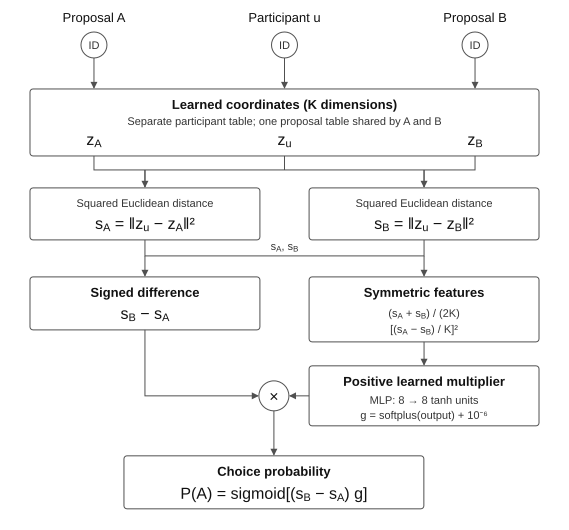

In [3]:
architecture_filename = {
    "original": "architecture.svg",
    "intermediate": "architecture_intermediate.svg",
}[VARIANT]
architecture_path = ROOT / "assets" / architecture_filename
svg_source = architecture_path.read_text()
if VARIANT == "intermediate":
    # Preserve the authored vector layout and label the saved network.
    widths = MODEL_SPECIFICATION["hidden_sizes"]
    assert all(
        isinstance(width, int) and not isinstance(width, bool) and width > 0 for width in widths
    )
    floor = float(MODEL_SPECIFICATION["minimum_scale"])
    assert 0 < floor < 1
    network_label = (
        "MLP: " + " → ".join(map(str, widths)) + " tanh units"
        if widths
        else "Linear scale output"
    )
    svg_source = svg_source.replace("MLP: 8 → 8 tanh units", network_label)
    svg_source = svg_source.replace(
        "an eight-by-eight tanh network", "the saved shared network"
    )
    if floor != 1e-6:
        svg_source = svg_source.replace(
            "g = softplus(output) + 10⁻⁶", f"g = softplus(output) + {floor:g}"
        )
    if len(network_label) > 28:
        svg_source = svg_source.replace(
            'y="404" class="small"',
            f'y="404" class="small" style="font-size:{11*28/len(network_label):.2f}px"',
        )
# Fig. 2A is an authored vector diagram, not a data-derived result.
# Display and export the same in-memory source, including its current labels.
svg_renderer = shutil.which("rsvg-convert")
assert (
    svg_renderer
), "Install librsvg (macOS: brew install librsvg; Debian/Ubuntu: librsvg2-bin)."
display(SVG(data=svg_source))
(PANELS / "architecture_selected.svg").write_text(svg_source)
diagram_export = subprocess.run(
    [svg_renderer, "--format=pdf", "--output", str(PANELS / "Fig2a.pdf")],
    input=svg_source.encode("utf-8"),
    check=True,
)


## Figure 2b: evolution of the main Chilean fit

The snapshots come from the same fitted sample at epochs 0, 5, 10 and 20. Each person appears once. Participants with consistent scores 0–1 or 9–10 are identified after estimation. The displayed labels do not enter training.

The Gaussian KDE uses Scott bandwidth, adjustment 1, a 200-point grid, support extending three bandwidths, ten levels, threshold 0.05 and common normalization. Every panel shows the full coordinate range from zero to one. Color, line type and marker distinguish the two groups.

In [4]:
snapshots = {}
summary_rows = []
epoch_files = {epoch: f"coordsU_epoch_{epoch}.csv" for epoch in SNAPSHOT_EPOCHS}
group_order = ["Far left (0–1)", "Far right (9–10)"]
for epoch, filename in epoch_files.items():
    coordinates = pd.read_csv(DATA / filename)
    assert list(coordinates.columns) == ["uuid", "z1", "z2", "politica"]
    assert coordinates.uuid.is_unique
    assert np.isfinite(coordinates[["z1", "z2"]]).all().all()
    far_left = coordinates.loc[coordinates.politica.between(0, 1)].copy()
    far_right = coordinates.loc[coordinates.politica.between(9, 10)].copy()
    far_left["group"] = group_order[0]
    far_right["group"] = group_order[1]
    selected = pd.concat([far_left, far_right], ignore_index=True)
    snapshots[epoch] = selected
    for group in group_order:
        subset = selected.loc[selected.group.eq(group)]
        summary_rows.append(
            {
                "epoch": epoch,
                "source_rows": len(coordinates),
                "group": group,
                "plotted_rows": len(subset),
                "z1_min": subset.z1.min(),
                "z1_max": subset.z1.max(),
                "z2_min": subset.z2.min(),
                "z2_max": subset.z2.max(),
            }
        )
training_snapshot_summary = pd.DataFrame(summary_rows)
display(training_snapshot_summary)
training_snapshot_summary.to_csv(TABLES / "training_snapshot_summary.csv", index=False)
training_snapshot_summary.to_latex(
    TABLES / "training_snapshot_summary.tex", index=False, float_format="%.6f", escape=True
)


,epoch,source_rows,group,plotted_rows,z1_min,z1_max,z2_min,z2_max
0,0,37100,Far left (0–1),2656,0.464651,0.544511,0.460346,0.541491
1,0,37100,Far right (9–10),1545,0.460370,0.542482,0.458248,0.544504
2,5,37100,Far left (0–1),2656,0.250097,0.729096,0.207303,0.736350
3,5,37100,Far right (9–10),1545,0.297359,0.714191,0.153686,0.657024
4,10,37100,Far left (0–1),2656,0.142629,0.818884,0.121327,0.848415
5,10,37100,Far right (9–10),1545,0.171767,0.775682,0.066860,0.769284
6,20,37100,Far left (0–1),2656,0.022740,0.906482,0.057972,0.940945
7,20,37100,Far right (9–10),1545,0.043100,0.882101,0.011803,0.904260


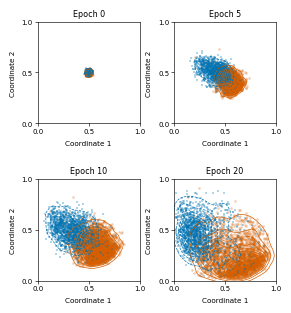

In [5]:
with plt.rc_context(
    {
        "font.size": 5.2,
        "axes.labelsize": 5.2,
        "xtick.labelsize": 5.0,
        "ytick.labelsize": 5.0,
        "axes.linewidth": 0.45,
        "xtick.major.width": 0.45,
        "ytick.major.width": 0.45,
    }
):
    fig, axes = plt.subplots(2, 2, figsize=(209.25 / 72, 226.25 / 72))
    palette = {group_order[0]: "#D55E00", group_order[1]: "#0072B2"}
    for ax, (epoch, selected) in zip(axes.flat, snapshots.items()):
        sns.kdeplot(
            data=selected,
            x="z2",
            y="z1",
            hue="group",
            hue_order=group_order,
            palette=palette,
            ax=ax,
            legend=False,
            bw_method="scott",
            bw_adjust=1,
            gridsize=200,
            cut=3,
            levels=10,
            thresh=0.05,
            common_norm=True,
            linewidths=0.5,
        )
        # Seaborn returns one contour collection per hue in the specified order.
        for collection, line_style in zip(ax.collections, ["solid", "dashed"]):
            collection.set_linestyle(line_style)
        for group, marker in zip(group_order, ["o", "s"]):
            subset = selected.loc[selected.group.eq(group)]
            ax.scatter(
                subset.z2,
                subset.z1,
                s=3.5,
                marker=marker,
                color=palette[group],
                alpha=0.3,
                linewidths=0,
            )
        ax.set(
            xlim=(0, 1),
            ylim=(0, 1),
            xticks=[0, 0.5, 1],
            yticks=[0, 0.5, 1],
            xlabel="Coordinate 1",
            ylabel="Coordinate 2",
        )
        ax.set_aspect("equal")
        ax.tick_params(length=2, pad=1.5)
        ax.text(
            0.5,
            1.035,
            f"Epoch {epoch}",
            transform=ax.transAxes,
            ha="center",
            va="bottom",
            fontsize=5.8,
        )
    fig.subplots_adjust(left=0.14, right=0.96, bottom=0.09, top=0.95, wspace=0.34, hspace=0.39)
    display(fig)
    fig.savefig(PANELS / "Fig2b.pdf", format="pdf", facecolor="white")
    plt.close(fig)


## Figure S1: training and held-out metrics

The input contains 20 epochs from each supplied country model. The CSV column names use “Validation”, while the figure labels these values “Held-out” to distinguish choice prediction from ideological classification. The curves display the recorded epoch metrics without smoothing. Accuracy lies between zero and one. Binary cross-entropy is nonnegative and can exceed one.

In [6]:
training_curves = pd.read_csv(DATA / "DataTraining_and_Validation_Accuracy_Loss.csv")
countries = ["Chile", "France", "Brazil"]
metric_columns = [
    "Training Accuracy",
    "Validation Accuracy",
    "Training Loss",
    "Validation Loss",
]
assert set(training_curves.Country) == set(countries)
assert not training_curves.duplicated(["Country", "Epoch"]).any()
assert np.isfinite(training_curves[metric_columns]).all().all()
assert training_curves[metric_columns].ge(0).all().all()
assert training_curves[["Training Accuracy", "Validation Accuracy"]].le(1).all().all()
for country in countries:
    epochs = training_curves.loc[training_curves.Country.eq(country), "Epoch"].tolist()
    assert epochs == list(range(1, len(epochs) + 1))
with pd.option_context("display.max_rows", 60):
    display(training_curves)
training_curves.to_csv(TABLES / "training_curves.csv", index=False)
training_curves.to_latex(
    TABLES / "training_curves.tex", index=False, float_format="%.4f", escape=True
)


,Epoch,Country,Training Accuracy,Validation Accuracy,Training Loss,Validation Loss
0,1,Chile,0.665072,0.664806,0.610236,0.611114
1,2,Chile,0.684641,0.680313,0.589495,0.597038
2,3,Chile,0.700570,0.686230,0.571627,0.589006
3,4,Chile,0.707414,0.689353,0.562798,0.584372
4,5,Chile,0.710255,0.689268,0.558853,0.584209
5,6,Chile,0.712011,0.689787,0.556674,0.583044
6,7,Chile,0.712960,0.689178,0.555557,0.586063
7,8,Chile,0.713375,0.688947,0.555012,0.585880
8,9,Chile,0.713529,0.687716,0.554830,0.590195
9,10,Chile,0.713610,0.687454,0.554812,0.588780


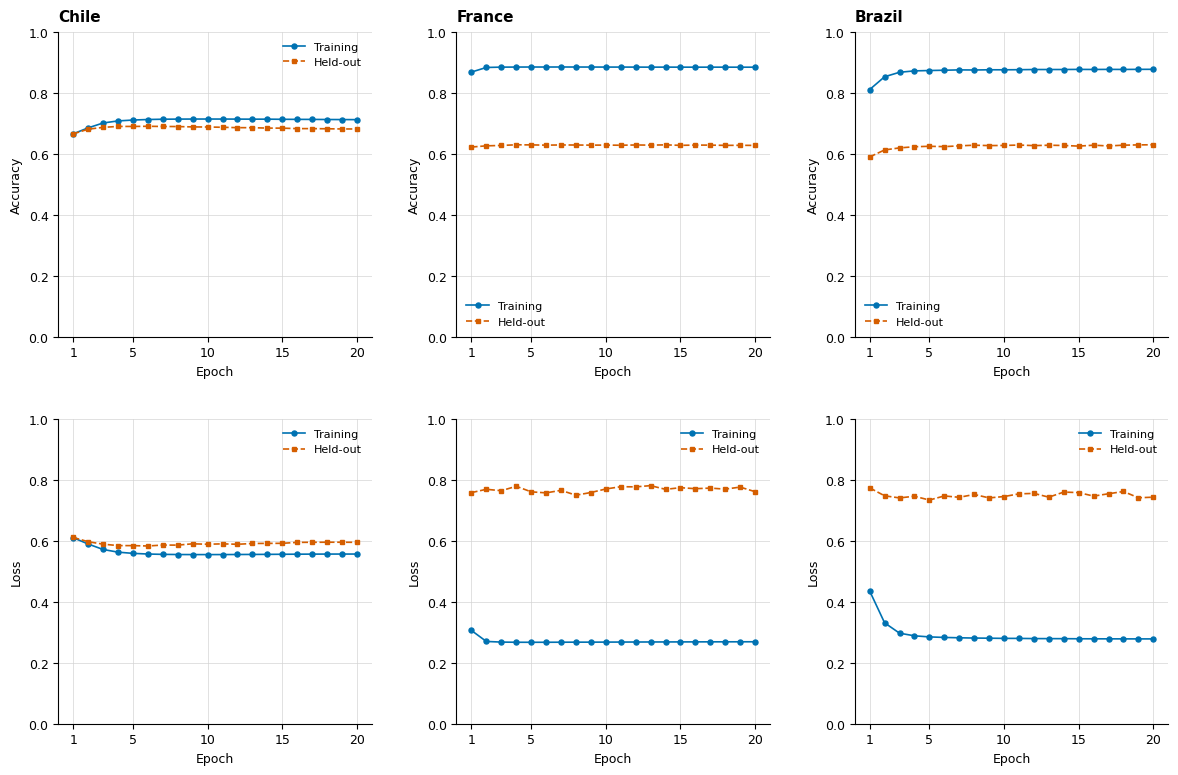

In [7]:
maximum_epoch = int(training_curves.Epoch.max())
epoch_ticks = sorted(set([1] + list(range(5, maximum_epoch + 1, 5)) + [maximum_epoch]))
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True)
for column, country in enumerate(countries):
    rows = training_curves.loc[training_curves.Country.eq(country)]
    for row, metric in enumerate(["Accuracy", "Loss"]):
        ax = axes[row, column]
        ax.plot(
            rows.Epoch,
            rows[f"Training {metric}"],
            color="#0072B2",
            marker="o",
            markersize=3.6,
            linewidth=1.2,
            label="Training",
        )
        ax.plot(
            rows.Epoch,
            rows[f"Validation {metric}"],
            color="#D55E00",
            marker="s",
            markersize=3.2,
            linestyle="--",
            linewidth=1.2,
            label="Held-out",
        )
        upper = (
            1
            if metric == "Accuracy"
            else max(1, 1.05 * rows[["Training Loss", "Validation Loss"]].to_numpy().max())
        )
        ax.set(
            ylim=(0, upper),
            xlim=(0, maximum_epoch + 1),
            xticks=epoch_ticks,
            xlabel="Epoch",
            ylabel=metric,
        )
        ax.tick_params(labelbottom=True)
        ax.grid(color="0.83", linewidth=0.5)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
        ax.legend(frameon=False, fontsize=8)
    axes[0, column].text(
        0,
        1.035,
        country,
        transform=axes[0, column].transAxes,
        fontsize=11,
        fontweight="bold",
        ha="left",
    )
fig.subplots_adjust(left=0.065, right=0.99, top=0.94, bottom=0.075, wspace=0.27, hspace=0.27)
display(fig)
fig.savefig(FIGURES / "FigS1.pdf", format="pdf", facecolor="white")
plt.close(fig)
